In [53]:
# Inisialisasi Direktori dan Konstanta Proyek
import os

DATASET_DIR = "dataset"
MODEL_DIR = "model"

os.makedirs(MODEL_DIR, exist_ok=True)

In [54]:
# Memuat Dataset Caption Gambar
import os
import pandas as pd

def load_captions():
    path = os.path.join(DATASET_DIR, "captions.xlsx")
    df = pd.read_excel(path)
    df.columns = df.columns.str.lower()
    df["caption"] = df["caption"].astype(str)
    return df


In [55]:
# Preprocessing Teks Caption
def clean_caption(text):
    text = text.lower().strip()
    text = ''.join(c for c in text if c.isalnum() or c.isspace())
    return f"startseq {text} endseq"

In [56]:
# Pembersihan dan Persiapan Data Caption
df = load_captions()
df["cleaned"] = df["caption"].apply(clean_caption)

captions = df["cleaned"].tolist()
filenames = df["filename"].tolist()


In [57]:
# Fungsi Ekstraksi Fitur Gambar
import numpy as np
from PIL import Image
from tensorflow.keras.applications.inception_v3 import preprocess_input

def extract_feature(img_path, model):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((299, 299))
    x = np.expand_dims(np.array(img), axis=0)
    x = preprocess_input(x)
    feat = model.predict(x, verbose=0)
    return feat.flatten()


In [58]:
# Inisialisasi Model CNN (InceptionV3) sebagai Encoder
from tensorflow.keras.applications.inception_v3 import InceptionV3

extractor = InceptionV3(
    include_top=False,
    weights="imagenet",
    pooling="avg"
)


In [59]:
# Ekstraksi Fitur Gambar dari Dataset
import os
import numpy as np

features = []
clean_caps = []

img_dir = os.path.join(DATASET_DIR, "images")

for i, fname in enumerate(filenames):
    img_path = os.path.join(img_dir, fname)

    if not os.path.exists(img_path):
        print("Missing:", img_path)
        continue

    feat = extract_feature(img_path, extractor)
    features.append(feat)
    clean_caps.append(captions[i])

features = np.array(features)


In [60]:
import os
import pickle
import re
from tensorflow.keras.preprocessing.text import Tokenizer

# ------------------ Fungsi untuk membersihkan caption ------------------
def remove_repeated_words(text):
    return re.sub(r'\b(\w+)( \1)+\b', r'\1', text)

def clean_caption(text):
    text = text.lower().strip()
    text = remove_repeated_words(text)
    text = ''.join(c for c in text if c.isalnum() or c.isspace())
    return f"startseq {text} endseq"

def split_and_clean(text):
    # Ambil caption pertama saja
    captions = [c.strip() for c in text.split('"') if c.strip()]
    if len(captions) == 0:
        return None
    return clean_caption(captions[0])

# ------------------ Preprocessing semua caption ------------------
all_captions = []
all_filenames = []

# Misal df["filename"] = nama file, df["caption"] = caption mentah
for fname, caps in zip(df["filename"], df["caption"]):
    clean_cap = split_and_clean(caps)
    if clean_cap is not None:
        all_captions.append(clean_cap)
        all_filenames.append(fname)

# ------------------ Tokenisasi ------------------
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)

# Simpan tokenizer dan max_length
os.makedirs(MODEL_DIR, exist_ok=True)
with open(os.path.join(MODEL_DIR, "tokenizer.pkl"), "wb") as f:
    pickle.dump(tokenizer, f)

with open(os.path.join(MODEL_DIR, "max_length.pkl"), "wb") as f:
    pickle.dump(max_length, f)

print("Vocab size:", vocab_size)
print("Max length:", max_length)


Vocab size: 662
Max length: 23


In [61]:
# Pembuatan Data Training Berbasis Sequence
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

X1, X2, y = [], [], []

for i, cap in enumerate(clean_caps):
    seq = tokenizer.texts_to_sequences([cap])[0]

    for j in range(1, len(seq)):
        in_seq, out = seq[:j], seq[j]

        in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
        out = tf.keras.utils.to_categorical(out, num_classes=vocab_size)

        X1.append(features[i])
        X2.append(in_seq)
        y.append(out)

X1 = np.array(X1)
X2 = np.array(X2)
y = np.array(y)

print(X1.shape, X2.shape, y.shape)


(3293, 2048) (3293, 23) (3293, 662)


In [62]:
# Perancangan Arsitektur Model Image Captioning (Encoder–Decoder)
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Dropout, add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def define_model(vocab_size, max_len):
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.6)(inputs1)
    fe2 = Dense(64, activation="relu")(fe1)

    inputs2 = Input(shape=(max_len,))
    se1 = Embedding(vocab_size,128, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(64)(se2)

    decoder = add([fe2, se3])
    decoder = Dense(64, activation="relu")(decoder)
    outputs = Dense(vocab_size, activation="softmax")(decoder)

    model = Model([inputs1, inputs2], outputs)
    optimizer = Adam(learning_rate=0.0005)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=optimizer,
        metrics=["accuracy"]
    )
    return model


In [63]:
# Inisialisasi dan Ringkasan Model

model = define_model(vocab_size, max_length)
model.summary()


Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 23)]         0           []                               
                                                                                                  
 input_11 (InputLayer)          [(None, 2048)]       0           []                               
                                                                                                  
 embedding_3 (Embedding)        (None, 23, 128)      84736       ['input_12[0][0]']               
                                                                                                  
 dropout_6 (Dropout)            (None, 2048)         0           ['input_11[0][0]']               
                                                                                            

In [64]:

import tensorflow as tf

# Simpan model terbaik
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    os.path.join(MODEL_DIR, "model_best.h5"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


history = model.fit(
    [X1, X2], y,
    epochs=20,                # bisa besar, tapi akan berhenti lebih awal jika stagnan
    batch_size=32,
    validation_split=0.2,
    callbacks=[checkpoint]
)


Epoch 1/20
80/83 [===========================>..] - ETA: 0s - loss: 5.8978 - accuracy: 0.0496
Epoch 1: val_loss improved from inf to 5.31947, saving model to model\model_best.h5
83/83 [==============================] - 5s 27ms/step - loss: 5.8742 - accuracy: 0.0520 - val_loss: 5.3195 - val_accuracy: 0.0941
Epoch 2/20
81/83 [============================>.] - ETA: 0s - loss: 5.2235 - accuracy: 0.0984
Epoch 2: val_loss improved from 5.31947 to 5.21379, saving model to model\model_best.h5
83/83 [==============================] - 1s 15ms/step - loss: 5.2264 - accuracy: 0.0991 - val_loss: 5.2138 - val_accuracy: 0.1396
Epoch 3/20
81/83 [============================>.] - ETA: 0s - loss: 5.0284 - accuracy: 0.1466
Epoch 3: val_loss improved from 5.21379 to 5.15328, saving model to model\model_best.h5
83/83 [==============================] - 1s 14ms/step - loss: 5.0339 - accuracy: 0.1465 - val_loss: 5.1533 - val_accuracy: 0.1517
Epoch 4/20
83/83 [==============================] - ETA: 0s - loss: 

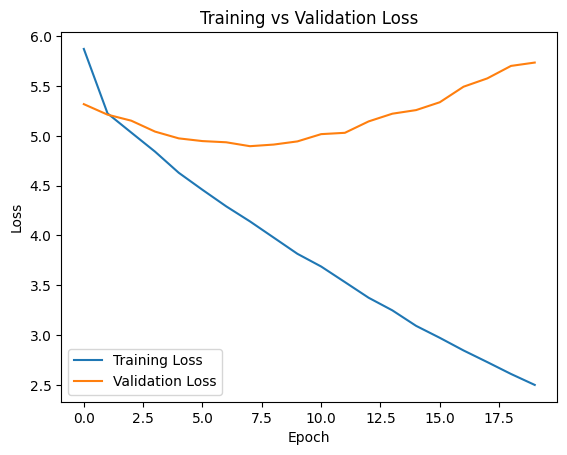

In [65]:
# Visualisasi Hasil Training (Loss dan Validation Loss)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [66]:
# Penyimpanan Model dan Riwayat Training
import pickle

with open(os.path.join(MODEL_DIR, "history.pkl"), "wb") as f:
    pickle.dump(history.history, f)

model.save(os.path.join(MODEL_DIR, "model_final.h5"))

print("Training completed!")


Training completed!


In [67]:
def generate_caption_no_repeat(model, tokenizer, photo_feature, max_length):
    in_text = 'startseq'
    used_words = set()  # Menyimpan kata yang sudah dipakai
    for _ in range(max_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([np.array([photo_feature]), sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = tokenizer.index_word.get(yhat, None)
        if word is None:
            break
        # Jika kata sudah digunakan, hentikan atau bisa skip (pilihan Anda)
        if word in used_words:
            break
        used_words.add(word)
        in_text += ' ' + word
        if word == 'endseq':
            break
    final_caption = in_text.replace('startseq', '').replace('endseq', '').strip()
    return final_caption


In [68]:
# ---------------- Prediksi Caption untuk 5 Gambar ----------------
test_images = [
    "test/test1.jpg",
    "test/test2.jfif",
    "test/test3.jpg",
    "test/test4.jpg",
    "test/test5.jpg"
]

for img_path in test_images:
    # Ekstrak fitur gambar
    photo_feature = extract_feature(img_path, extractor)
    
    # Generate caption tanpa kata berulang
    caption = generate_caption_no_repeat(model, tokenizer, photo_feature, max_length)
    
    # Tampilkan hasil
    print(f"Gambar: {img_path}")
    print("Caption Prediksi:", caption)
    print("-" * 50)


Gambar: test/test1.jpg
Caption Prediksi: seorang anak bayi mengenakan
--------------------------------------------------
Gambar: test/test2.jfif
Caption Prediksi: seorang pendaki sedang tebing
--------------------------------------------------
Gambar: test/test3.jpg
Caption Prediksi: seekor anjing hitam berlari di mulutnya
--------------------------------------------------
Gambar: test/test4.jpg
Caption Prediksi: seorang pendaki mendaki gunung di pegunungan
--------------------------------------------------
Gambar: test/test5.jpg
Caption Prediksi: seorang pria di ke
--------------------------------------------------


In [69]:
# ---------------- Prediksi Caption ----------------
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

test_image_path = "test/test2.jfif"
reference_caption = "Seorang pria sedang memanjat tebing"  # caption asli / ground truth

# Ekstrak fitur gambar
photo_feature = extract_feature(test_image_path, extractor)
# Generate caption
caption = generate_caption_no_repeat(model, tokenizer, photo_feature, max_length)

print("Caption Prediksi:", caption)
print("Caption Referensi:", reference_caption)

# ---------------- Hitung BLEU ----------------
smooth_fn = SmoothingFunction().method1
bleu1 = sentence_bleu([reference_caption.split()], caption.split(), weights=(1,0,0,0), smoothing_function=smooth_fn)
bleu2 = sentence_bleu([reference_caption.split()], caption.split(), weights=(0.5,0.5,0,0), smoothing_function=smooth_fn)
bleu3 = sentence_bleu([reference_caption.split()], caption.split(), weights=(0.33,0.33,0.33,0), smoothing_function=smooth_fn)
bleu4 = sentence_bleu([reference_caption.split()], caption.split(), weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn)

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

Caption Prediksi: seorang pendaki sedang tebing
Caption Referensi: Seorang pria sedang memanjat tebing
BLEU-1: 0.3894
BLEU-2: 0.1005
BLEU-3: 0.0750
BLEU-4: 0.0744
